In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm
from magnonics import *

In [2]:
hamil, lat, basis = Initialize.from_csv('configs/kagome.csv')

hamil.HP_trafo(symbolic=True)

hamil.parameterize_hamil()

Automatically finding sufficient chemical potential...
Using 1e-10 as chemical potential.


1e-10

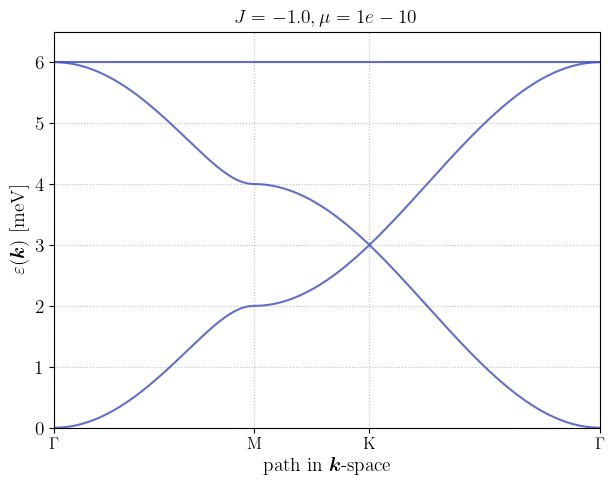

In [3]:
bz = Hexagonal(hamil, 'kagome_test')
hsp = bz.hsp
disp = bz.get_dispersion(hsp.g, hsp.m, hsp.k, hsp.g, num = 200)
fig = bz.plot_bandstructure(disp, show_params=True, show_chern=False)
bz.save_plot(fig, overwrite=True)
plt.show()

In [3]:
hamil.update_parameters({'Dz': -0.1}, 1e-8)

Updated parameters and now using 1e-08 as chemical potential.


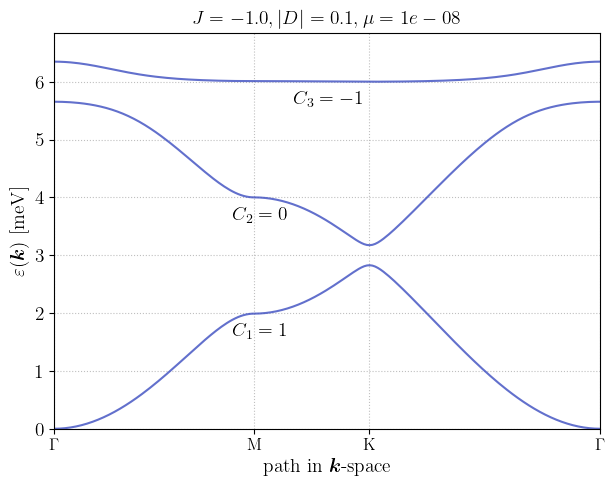

In [4]:
bz = Hexagonal(hamil, 'kagome_test')
hsp = bz.hsp
disp = bz.get_dispersion(hsp.g, hsp.m, hsp.k, hsp.g, num = 200)
fig = bz.plot_bandstructure(disp, show_params=True, show_chern=True)
bz.save_plot(fig, overwrite=True)
plt.show()

In [5]:
C, F, E = hamil.abelian_chern(10)
print(C[:len(C) // 2])

Calculating eigenvectors on 10x10 grid...
[ 1.  0. -1.]


In [6]:
Es, EVs = hamil.evgrid(50)

chern_numbers = np.around(hamil.chern(EVs), 2)

print(chern_numbers[:len(chern_numbers) // 2])
print(np.sum(chern_numbers[:len(chern_numbers) // 2],0)) # NOTE check for order of Chern numbers: in papers it is given from top to bottom -1,0,1 (current DMI in input file has reversed signs)

[-1.  0.  1.]
0.0


Processing 3 bands with mixed shapes...


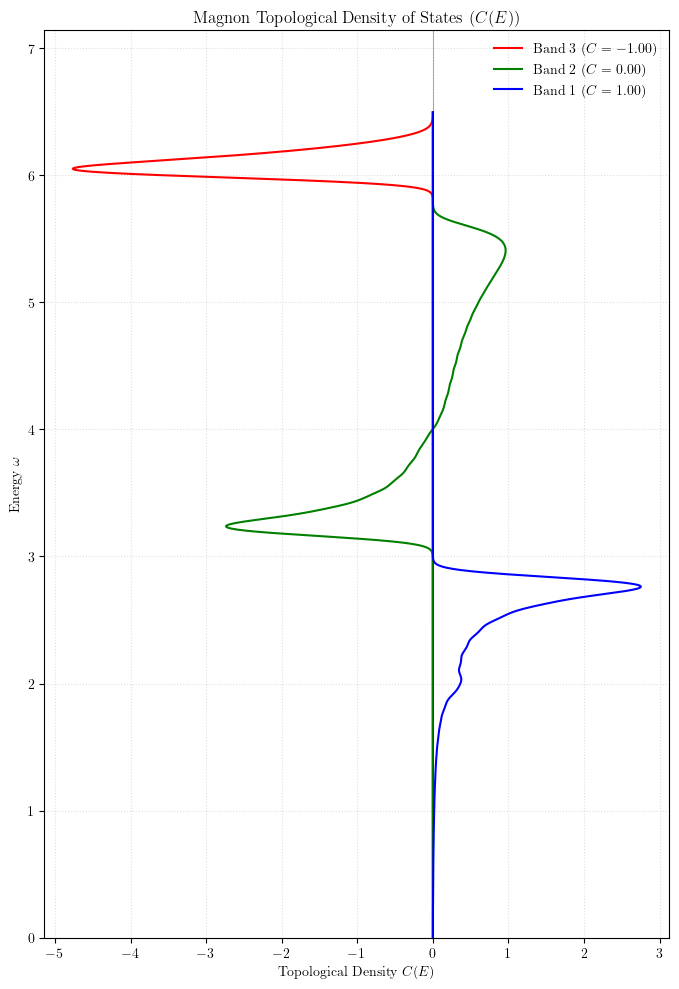

In [12]:
# params
sigma = 0.05
n_points = 5000
F_12 = - hamil.curvature_grid(EVs)

n_bands = F_12.shape[0]  # Get number of bands from the leading dim of F_12
    
# 1. Setup Energy Axis
e_min, e_max = np.min(Es) - 3*sigma, np.max(Es) + 3*sigma
energy_axis = np.linspace(e_min, e_max, n_points)

chern_density = np.zeros((n_points, n_bands))

print(f"Processing {n_bands // 2} bands with mixed shapes...")
for b in range(n_bands // 2):
    # F_12 is (Nbands, Nk1-1, Nk2-1) -> e.g., (N, 9, 9)
    # E is (Nk1, Nk2, Nbands) -> e.g., (10, 10, N)
    
    # 1. Match the shapes
    # We take the energy of the bottom-left corner of each plaquette
    nk1_flux, nk2_flux = F_12.shape[1], F_12.shape[2]
    
    energies_b = Es[:nk1_flux, :nk2_flux, b].ravel() # Slice E to (9, 9)
    flux_b = F_12[b].ravel()                        # Already (9, 9)
    
    # Now both are length 81
    diff = energy_axis[:, np.newaxis] - energies_b[np.newaxis, :]
    weights = (1.0 / (np.sqrt(2 * np.pi) * sigma)) * np.exp(-0.5 * (diff / sigma)**2)
    
    chern_density[:, b] = (weights @ flux_b) / (2 * np.pi)

# 4. Visualization
plt.figure(figsize=(7, 10))
total_density = np.sum(chern_density, axis=1)

colors = ['r', 'g', 'b', 'c', 'm', 'y']

for b in range(n_bands//2):
    c_val = np.sum(F_12[b]) / (2 * np.pi)
    plt.plot(chern_density[:, b], energy_axis, 
                label=f'Band {n_bands // 2 - b} ($C={c_val:.2f}$)', color=colors[b])

# plt.plot(total_density, energy_axis, 'k--', alpha=0.5, label='Total Sum')

plt.axvline(0, color='black', lw=0.8, alpha=0.3)
plt.xlabel(r"Topological Density $C(E)$")
plt.ylabel(r"Energy $\omega$")
plt.title(r"Magnon Topological Density of States ($C(E)$)")
plt.legend(frameon=False)
plt.grid(True, linestyle=':', alpha=0.4)
plt.tight_layout()
plt.ylim(ymin=0)
plt.show()

In [ ]:
from scipy.special import spence # spence(x) is Li2(x) in scipy

def thermal_weight_function(E, T, kB=0.08617):
    """
    Calculates the [c2(nB) - pi^2/3] weight factor.
    kB is in meV/K if E is in meV.
    """
    # Avoid division by zero at E=0
    x = 1.0 / (np.exp(E / (kB * T)) - 1.0)
    
    # c2(x) formula
    # Li2(-x) is represented by spence(1+x) in some conventions, 
    # but scipy's spence(z) is Li2(z). So we use spence(-x).
    term1 = (1 + x) * (np.log((1 + x) / x))**2
    term2 = (np.log(x))**2
    term3 = 2 * spence(-x)
    
    return (term1 - term2 - term3) - (np.pi**2 / 3.0)

def calculate_kappa_xy(energy_axis, chern_density, temperatures):
    """
    Parameters:
    -----------
    energy_axis : (n_points,)
    chern_density : (n_points, n_bands) 
    temperatures : list or array of T values
    """
    hbar = 6.5821e-13 # meV*s
    kB = 0.08617      # meV/K
    
    # Total C(E) summed over all bands
    total_C_E = np.sum(chern_density, axis=1)
    
    kappa_values = []
    
    # Integration step size
    dE = energy_axis[1] - energy_axis[0]
    
    for T in temperatures:
        if T == 0:
            kappa_values.append(0)
            continue
            
        # Calculate weights for this temperature
        weights = thermal_weight_function(energy_axis, T, kB)
        
        # Integrate: kappa ~ -T * sum( C(E) * weight * dE )
        # The units here will be (meV^2 / (K * s))
        integral = np.sum(total_C_E * weights) * dE
        kappa = -(kB**2 * T / hbar) * integral
        
        kappa_values.append(kappa)
        
    return np.array(kappa_values)

In [ ]:
hamil.update_parameters({'Dz': 0})

Updated parameters and now using 1e-08 as chemical potential.


In [ ]:
zigzag = hamil.create_slab(1,20)

In [ ]:
zigzag.HP_trafo()

zigzag.parameterize_hamil()

1e-08

In [ ]:
dir = hamil.lat.num_rcpr_vects[0]
ks = np.linspace(0, 1, 500)
energies = np.empty((len(ks), 2*zigzag.lat.n_sublats))
amps = np.empty((len(ks), zigzag.lat.n_sublats, zigzag.lat.n_sublats))
eigvects = np.empty((len(ks), 2*zigzag.lat.n_sublats, 2*zigzag.lat.n_sublats), dtype='complex')

for i, j in enumerate(ks):
    k = j*dir # cut dir vector into len(ks)-1 pieces
    E, EV = zigzag.Bogoliubov_trafo(k[0], k[1], k[2])
    amp = zigzag.sublat_localization(EV)
    energies[i] = E
    amps[i] = amp
    eigvects[i] = EV

energies = energies[:, :len(energies[1]) // 2]

In [ ]:
layers = 5
loc = amps[:, :, -8:].sum(axis=-1) - amps[:, :, :8].sum(axis=-1)

tol = 1e-5 #zigzag.parameters['chempot']
degen_mask = np.zeros_like(energies, dtype=bool)

nk, nbands = energies.shape

for i in range(nk):
    e_on_k = energies[i, :]

    for j in range(nbands):
        if j > 0 and np.abs(e_on_k[j] - e_on_k[j-1]) < tol:
            degen_mask[i, j] = True
        if j < (nbands-1) and np.abs(e_on_k[j] - e_on_k[j+1]) < tol:
            degen_mask[i, j] = True

loc[degen_mask] = 0

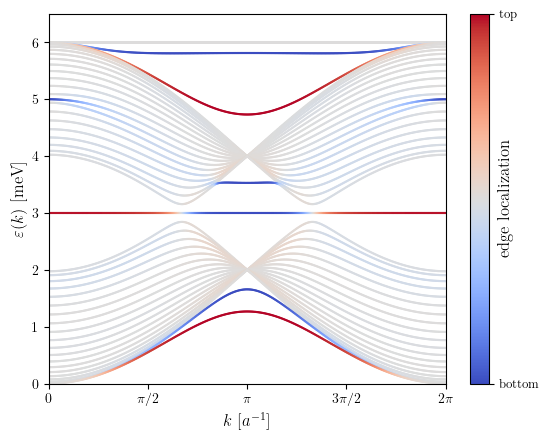

In [ ]:
for i in range(nbands):
    bandplot = plt.scatter(ks, energies[:,i], marker = '.', c = loc[:, i], edgecolor='none', cmap = 'coolwarm', vmin = -1.0, vmax = 1.0, s = 10)

cbar = plt.colorbar(bandplot)
cbar.set_label('edge localization', fontsize = 12)
cbar.set_ticks([-1, 1])
cbar.set_ticklabels(['bottom', 'top'])
cbar.ax.yaxis.set_label_coords(1.5, 0.5)
cbar.ax.tick_params(labelsize = 9)

tick_positions = [0, 0.25, 0.5, 0.75, 1]
tick_labels = [r"$0$", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"]
plt.xticks(tick_positions, tick_labels)
plt.xlabel(r'$k \, \, [a^{-1}]$', fontsize=12)
plt.ylabel(r'$\varepsilon(k) \, \, [\mathrm{meV}]$', fontsize=12)
plt.margins(x=0, y=0)
plt.ylim(0,6.5)
plt.savefig('slab_test.pdf', facecolor='w', transparent=False, dpi = 600)

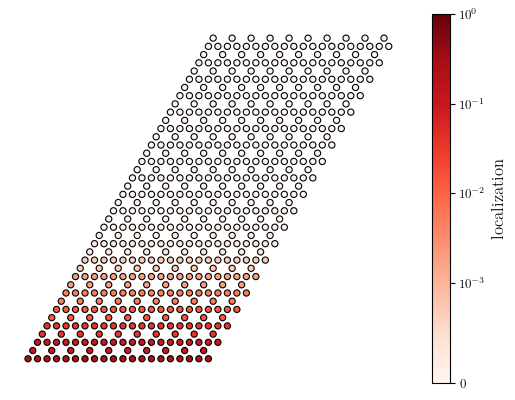

In [ ]:
points = np.array([zigzag.lat.sublats[i].num_basisvect[0:2] for i in range(0, len(zigzag.lat.sublats))])

k_lat = 0.6
E_lat = 3
k_index = np.abs(ks - k_lat).argmin()
band_index = np.abs(energies[k_index] - E_lat).argmin()

# plt.figure(figsize=(10,10))
for i in range(10):
    latticeplot = plt.scatter(points[:, 0] + i * (zigzag.lat.num_vects[0,0] + zigzag.lat.num_vects[1,0]), points[:, 1], marker = "o", edgecolors = "black", linewidths = 0.8, s = 20, c = amps[k_index, band_index][:], cmap = 'Reds', norm = SymLogNorm(0.001, vmin=0, vmax=1))

cbar2 = plt.colorbar(latticeplot) # orientation='horizontal'
cbar2.set_label('localization', fontsize = 12)
cbar2.set_ticks([1, 10**-1, 10**-2, 10**-3, 0])
cbar2.ax.tick_params(labelsize = 9)


plt.axis('off')
plt.axis("equal")
plt.savefig('lattice_test.pdf', facecolor='w', transparent=False, dpi = 600)

In [ ]:
hamil2, lat2, basis2 = Initialize.from_csv('configs/kagome_armchair.csv')

hamil2.HP_trafo(symbolic=True)

hamil2.parameterize_hamil() # 1e-8

Automatically finding sufficient chemical potential...
Using 1e-10 as chemical potential.


1e-10

In [ ]:
armchair = hamil2.create_slab(1, 5)

In [ ]:
armchair.parameters['Dz'] = '0.1'

In [ ]:
armchair.HP_trafo()

armchair.parameterize_hamil(1e-3)

0.001

In [ ]:
dir = hamil2.lat.num_rcpr_vects[0]
ks = np.linspace(0,1, 500)
energies = np.empty((len(ks), 2*armchair.lat.n_sublats))
amps = np.empty((len(ks), armchair.lat.n_sublats, armchair.lat.n_sublats))
eigvects = np.empty((len(ks), 2*armchair.lat.n_sublats, 2*armchair.lat.n_sublats), dtype='complex')

for i, j in enumerate(ks):
    k = j*dir # cut dir vector into len(ks)-1 pieces
    E, EV = armchair.Bogoliubov_trafo(k[0], k[1], k[2])
    amp = armchair.sublat_localization(EV)
    energies[i] = E
    amps[i] = amp
    eigvects[i] = EV

energies = energies[:, :len(energies[1]) // 2]

In [ ]:
layers = 5
loc = amps[:, :, -8:].sum(axis=-1) - amps[:, :, :8].sum(axis=-1)

tol = 1e-5 #zigzag.parameters['chempot']
degen_mask = np.zeros_like(energies, dtype=bool)

nk, nbands = energies.shape

for i in range(nk):
    e_on_k = energies[i, :]

    for j in range(nbands):
        if j > 0 and np.abs(e_on_k[j] - e_on_k[j-1]) < tol:
            degen_mask[i, j] = True
        if j < (nbands-1) and np.abs(e_on_k[j] - e_on_k[j+1]) < tol:
            degen_mask[i, j] = True

loc[degen_mask] = 0

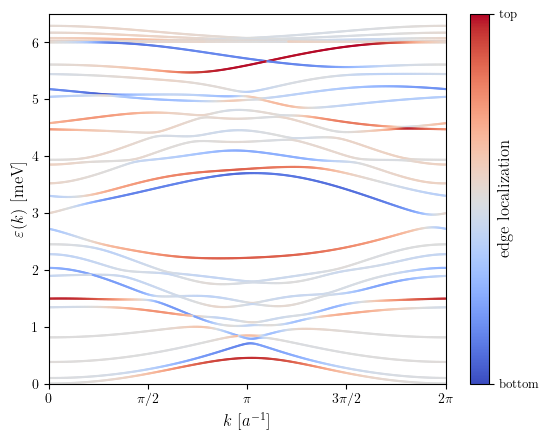

In [ ]:
for i in range(nbands):
    bandplot = plt.scatter(ks, energies[:,i], marker = '.', c = loc[:, i], edgecolor='none', cmap = 'coolwarm', vmin = -1.0, vmax = 1.0, s = 10)

cbar = plt.colorbar(bandplot)
cbar.set_label('edge localization', fontsize = 12)
cbar.set_ticks([-1, 1])
cbar.set_ticklabels(['bottom', 'top'])
cbar.ax.yaxis.set_label_coords(1.5, 0.5)
cbar.ax.tick_params(labelsize = 9)

tick_positions = [0, 0.25, 0.5, 0.75, 1]
tick_labels = [r"$0$", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"]
plt.xticks(tick_positions, tick_labels)
plt.xlabel(r'$k \, \, [a^{-1}]$', fontsize=12)
plt.ylabel(r'$\varepsilon(k) \, \, [\mathrm{meV}]$', fontsize=12)
plt.margins(x=0, y=0)
plt.ylim(0,6.5)
plt.savefig('slab_test.pdf', facecolor='w', transparent=False, dpi = 600)

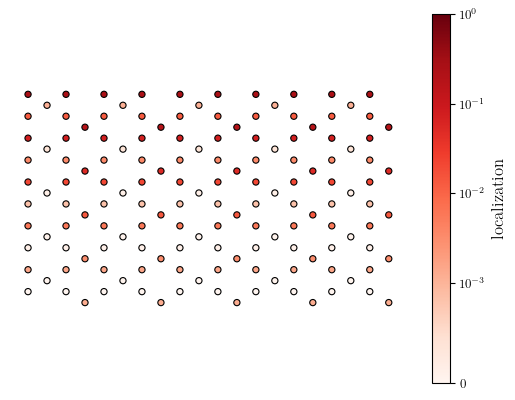

In [ ]:
points = np.array([armchair.lat.sublats[i].num_basisvect[0:2] for i in range(0, len(armchair.lat.sublats))])

k_lat = 0.5
E_lat = 2.5
k_index = np.abs(ks - k_lat).argmin()
band_index = np.abs(energies[k_index] - E_lat).argmin()

for i in range(5):
    latticeplot = plt.scatter(points[:, 0] + i * (armchair.lat.num_vects[0,0] + armchair.lat.num_vects[1,0]), points[:, 1], marker = "o", edgecolors = "black", linewidths = 0.8, s = 20, c = amps[k_index, band_index][:], cmap = 'Reds', norm = SymLogNorm(0.001, vmin=0, vmax=1))

cbar2 = plt.colorbar(latticeplot) # orientation='horizontal'
cbar2.set_label('localization', fontsize = 12)
cbar2.set_ticks([1, 10**-1, 10**-2, 10**-3, 0])
cbar2.ax.tick_params(labelsize = 9)

plt.axis('off')
plt.axis("equal")
plt.savefig('lattice_test.pdf', facecolor='w', transparent=False, dpi = 600)